# Practical 20

**Aim:** Create various types of plots using Matplotlib: line plot, bar chart, histogram, pie chart, scatter plot using subplots and figure properties.

### 1. Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

mushroom_columns = ['poisonous', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
# Load the locally downloaded UCI Mushroom dataset
mushroom_file = 'agaricus-lepiota.data'
df = pd.read_csv(mushroom_file, header=None, names=mushroom_columns)
df.head(2)

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g


### 2. Line Plot, Bar Chart, Histogram, Pie Chart, Scatter Plot using Subplots & Figure Properties

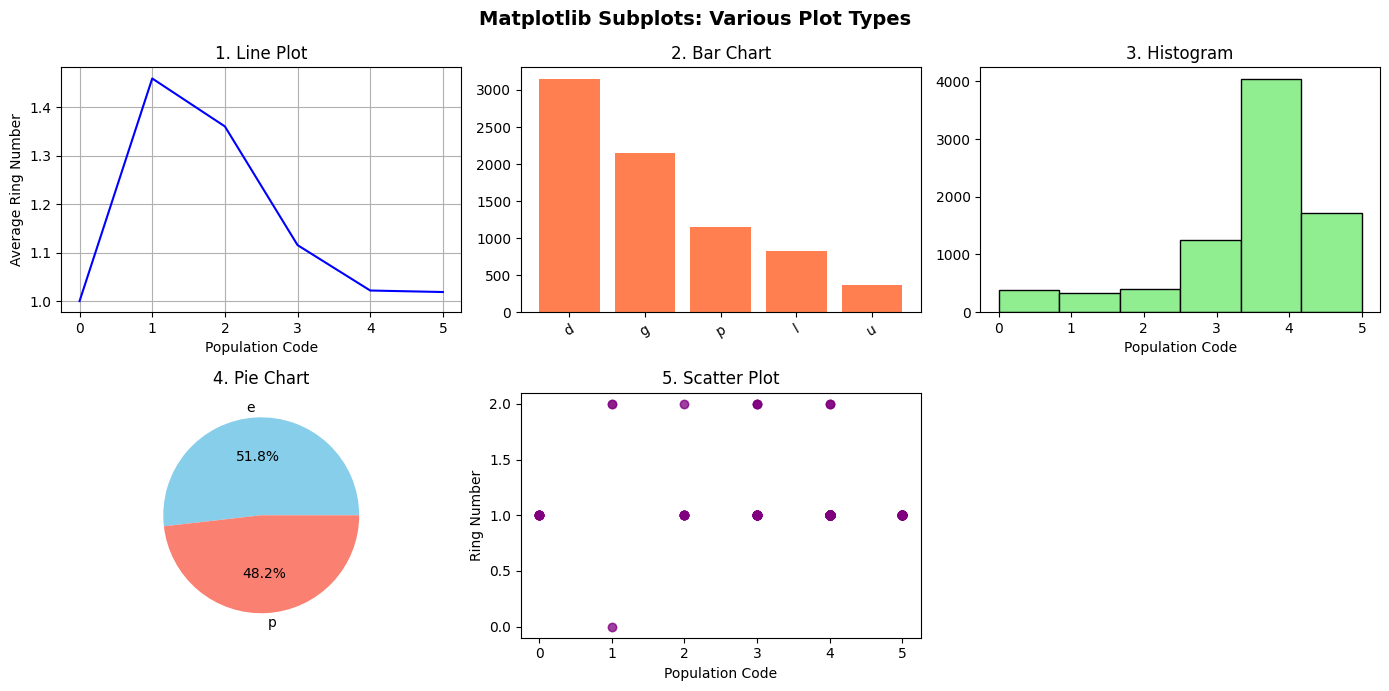

In [2]:
# Prepare aggregated/sample data
df['population_code'] = df['population'].astype('category').cat.codes
df['ring-number-code'] = df['ring-number'].map({'n': 0, 'o': 1, 't': 2})
population_ring = df.groupby('population_code')['ring-number-code'].mean()
top_habitat = df['habitat'].astype(str).str.strip().value_counts().head(5)
poisonous_counts = df['poisonous'].value_counts()
sample_df = df.sample(300, random_state=42)

# Create 2x3 Subplots with Figure Properties
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Matplotlib Subplots: Various Plot Types', fontsize=14, fontweight='bold')

# 1. Line Plot
axes[0, 0].plot(population_ring.index, population_ring.values, color='blue')
axes[0, 0].set_title('1. Line Plot')
axes[0, 0].set_xlabel('Population Code')
axes[0, 0].set_ylabel('Average Ring Number')
axes[0, 0].grid(True)

# 2. Bar Chart
axes[0, 1].bar(top_habitat.index, top_habitat.values, color='coral')
axes[0, 1].set_title('2. Bar Chart')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Histogram
axes[0, 2].hist(df['population_code'], bins=6, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('3. Histogram')
axes[0, 2].set_xlabel('Population Code')

# 4. Pie Chart
axes[1, 0].pie(poisonous_counts, labels=poisonous_counts.index, autopct='%1.1f%%', colors=['skyblue', 'salmon'])
axes[1, 0].set_title('4. Pie Chart')

# 5. Scatter Plot
axes[1, 1].scatter(sample_df['population_code'], sample_df['ring-number-code'], color='purple', alpha=0.5)
axes[1, 1].set_title('5. Scatter Plot')
axes[1, 1].set_xlabel('Population Code')
axes[1, 1].set_ylabel('Ring Number')

# Remove unused 6th subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()